# Content Recommendation

In [46]:
import pandas as pd
import numpy as np
import json

import matplotlib as plt
from matplotlib import pyplot as plt
import seaborn as sns
import seaborn # a library built on top of Matlab, to create and style statistical plots from Pandas and numpy

In [18]:
path_project = "/home/hhyamamura/workspace/contentRecommendation/"
# Load all raw json files
df_genome_scores = pd.read_csv(path_project+"ml-25m/genome_scores.csv")
df_genome_tags = pd.read_csv(path_project+"ml-25m/genome_tags.csv")
df_links = pd.read_csv(path_project+"ml-25m/links.csv", sep=',', quotechar='"',
                   skipinitialspace=True,)
df_movies = pd.read_csv(path_project+"ml-25m/movies.csv")
df_ratings = pd.read_csv(path_project+"ml-25m/ratings.csv")
df_tags = pd.read_csv(path_project+"ml-25m/tags.csv", sep=',', quotechar='"',
                   skipinitialspace=True,)
# df_genome_scores- movieId,tagId,relevance
# df_genome_tags- tagId,tag
# df_links- movieId,imdbId,tmdbId
# df_movies- movieId,title,genres
# df_ratings- userId,movieId,rating,timestamp
# df_tags- userId,movieId,tag,timestamp

In [23]:
print("genome_scores: \n")
display(df_genome_scores.info())

print("\n\ngenome_tags: \n")
display(df_genome_tags.info())

print("\n\nlinks: \n")
display(df_links.info())

print("\n\nmovies: \n")
display(df_movies.info())

print("\n\nratings: \n")
display(df_ratings.info())

print("\n\ntags: \n")
display(df_tags.info())

genome_scores: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15584448 entries, 0 to 15584447
Data columns (total 3 columns):
 #   Column     Dtype  
---  ------     -----  
 0   movieId    int64  
 1   tagId      int64  
 2   relevance  float64
dtypes: float64(1), int64(2)
memory usage: 356.7 MB


None



genome_tags: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tagId   1128 non-null   int64 
 1   tag     1128 non-null   object
dtypes: int64(1), object(1)
memory usage: 17.8+ KB


None



links: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62423 entries, 0 to 62422
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  62423 non-null  int64  
 1   imdbId   62423 non-null  int64  
 2   tmdbId   62316 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 1.4 MB


...

None



ratings: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000095 entries, 0 to 25000094
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 762.9 MB


None



tags: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1093360 entries, 0 to 1093359
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   userId     1093360 non-null  int64 
 1   movieId    1093360 non-null  int64 
 2   tag        1093344 non-null  object
 3   timestamp  1093360 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 33.4+ MB


None

In [20]:
print("genome_scores size: "+str(df_genome_scores.shape))
display(df_genome_scores.head(5))

print("genome_tags size: "+str(df_genome_tags.shape))
display(df_genome_tags.head(5))

print("links size: "+str(df_links.shape))
display(df_links.head(5))

print("movies size: "+str(df_movies.shape))
display(df_movies.head(5))

print("ratings size: "+str(df_ratings.shape))
display(df_ratings.head(5))

print("tags size: "+str(df_tags.shape))
display(df_tags.head(5))

genome_scores size: (15584448, 3)


,movieId,tagId,relevance
0,1,1,0.02875
1,1,2,0.02375
2,1,3,0.06250
3,1,4,0.07575
4,1,5,0.14075


genome_tags size: (1128, 2)


,tagId,tag
0,1,007
1,2,007 (series)
2,3,18th century
3,4,1920s
4,5,1930s


links size: (62423, 3)


...

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


ratings size: (25000095, 4)


,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


tags size: (1093360, 4)


,userId,movieId,tag,timestamp
0,3,260,classic,1439472355
1,3,260,sci-fi,1439472256
2,4,1732,dark comedy,1573943598
3,4,1732,great dialogue,1573943604
4,4,7569,so bad it's good,1573943455


Tag Genome (genome_scores.csv and genome_tags.csv)
--------
The tag genome is a data structure that contains tag relevance scores for movies. The structure is a dense matrix: each movie in the genome has a value for every tag in the genome.  
genome_scores.csv
* movieId,
* tagId,
* relevance

1,1,0.028749999999999998  
1,2,0.023749999999999993  

genome_tags.csv
* tagId
* tag

1,007  
2,007 (series)  
3,18th century  
4,1920s  
5,1930s  

links.csv
--------
Identifiers that can be used to link to other sources of movie data are contained in the file links.csv. Each line of this file after the header row represents one movie, and has the following format:
* movieId,
* imdbId,
* tmdbId

1,0114709,862  
2,0113497,8844  

movies.csv
--------
* movieId,
* title,
* genres

1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy  
2,Jumanji (1995),Adventure|Children|Fantasy


ratings.csv
--------
* userId,
* movieId,
* rating,
* timestamp

1,296,5.0,1147880044  
1,306,3.5,1147868817  

tags.csv
--------
* userId,
* movieId,
* tag,
* timestamp

3,260,classic,1439472355  
3,260,sci-fi,1439472256  
4,1732,dark comedy,1573943598  
4,1732,great dialogue,1573943604  
4,7569,so bad it's good,1573943455  
4,44665,unreliable narrators,1573943619  
4,115569,tense,1573943077  

In [21]:
display(df_genome_scores.isnull().sum())

display(df_genome_tags.isnull().sum())

display(df_links.isnull().sum())

display(df_movies.isnull().sum())

display(df_ratings.isnull().sum())

display(df_tags.isnull().sum())

movieId      0
tagId        0
relevance    0
dtype: int64

tagId    0
tag      0
dtype: int64

movieId      0
imdbId       0
tmdbId     107
dtype: int64

movieId    0
title      0
genres     0
dtype: int64

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

userId        0
movieId       0
tag          16
timestamp     0
dtype: int64

In [13]:
display(df_genome_scores.describe())
display(df_genome_tags.describe())
display(df_links.describe())
display(df_movies.describe())
display(df_ratings.describe())
display(df_tags.describe())

,movieId,tagId,relevance
count,1.558445e+07,1.558445e+07,1.558445e+07
mean,4.602249e+04,5.645000e+02,1.163679e-01
std,5.535221e+04,3.256254e+02,1.544722e-01
min,1.000000e+00,1.000000e+00,2.500000e-04
25%,3.853750e+03,2.827500e+02,2.400000e-02
50%,8.575500e+03,5.645000e+02,5.650000e-02
75%,8.018650e+04,8.462500e+02,1.407500e-01
max,2.064990e+05,1.128000e+03,1.000000e+00


,tagId
count,1128.000000
mean,564.500000
std,325.769857
min,1.000000
25%,282.750000
50%,564.500000
75%,846.250000
max,1128.000000


,movieId,imdbId,tmdbId
count,62423.000000,6.242300e+04,62316.000000
mean,122220.387646,1.456706e+06,155186.689999
std,63264.744844,2.098007e+06,153362.694700
min,1.000000,1.000000e+00,2.000000
25%,82146.500000,8.168650e+04,36768.750000
50%,138022.000000,3.258050e+05,86750.500000
75%,173222.000000,2.063724e+06,255255.250000
max,209171.000000,1.117094e+07,646282.000000


,movieId
count,62423.000000
mean,122220.387646
std,63264.744844
min,1.000000
25%,82146.500000
50%,138022.000000
75%,173222.000000
max,209171.000000


,userId,movieId,rating,timestamp
count,2.500010e+07,2.500010e+07,2.500010e+07,2.500010e+07
mean,8.118928e+04,2.138798e+04,3.533854e+00,1.215601e+09
std,4.679172e+04,3.919886e+04,1.060744e+00,2.268758e+08
min,1.000000e+00,1.000000e+00,5.000000e-01,7.896520e+08
25%,4.051000e+04,1.196000e+03,3.000000e+00,1.011747e+09
50%,8.091400e+04,2.947000e+03,3.500000e+00,1.198868e+09
75%,1.215570e+05,8.623000e+03,4.000000e+00,1.447205e+09
max,1.625410e+05,2.091710e+05,5.000000e+00,1.574328e+09


,userId,movieId,timestamp
count,1.093360e+06,1.093360e+06,1.093360e+06
mean,6.759022e+04,5.849276e+04,1.430115e+09
std,5.152114e+04,5.968731e+04,1.177384e+08
min,3.000000e+00,1.000000e+00,1.135429e+09
25%,1.520400e+04,3.504000e+03,1.339262e+09
50%,6.219900e+04,4.594000e+04,1.468929e+09
75%,1.136420e+05,1.029030e+05,1.527402e+09
max,1.625340e+05,2.090630e+05,1.574317e+09


In [38]:
# Check NULL values
# display(df_genome_scores[df_genome_scores.isnull().any(axis=1)])
# display(df_genome_tags[df_genome_tags.isnull().any(axis=1)])
display(df_links[df_links.isnull().any(axis=1)])
# display(df_movies[df_movies.isnull().any(axis=1)])
# display(df_ratings[df_ratings.isnull().any(axis=1)])
display(df_tags[df_tags.isnull().any(axis=1)])

,movieId,imdbId,tmdbId
706,721,114103,NaN
715,730,125877,NaN
754,770,38426,NaN
775,791,113610,NaN
1080,1107,102336,NaN
...,...,...,...
60459,203368,7952000,NaN
60681,203881,10575038,NaN
61576,206282,8773020,NaN
62339,208799,4035866,NaN


,userId,movieId,tag,timestamp
860902,121710,33826,NaN,1221450908
976395,141727,123,NaN,1199450867
976396,141727,346,NaN,1199451946
976400,141727,1184,NaN,1199452261
976407,141727,1785,NaN,1199452006
976408,141727,2194,NaN,1199450677
976410,141727,2691,NaN,1199451002
976418,141727,4103,NaN,1199451920
976420,141727,4473,NaN,1199451040
976422,141727,4616,NaN,1199452441


These indexes correspond to (line-2) from lists.csv and tags.csv

In [42]:
indices_with_nan = df_links[df_links.isnull().any(axis=1)].index
print("List indexes: \n")
print(np.array(indices_with_nan.tolist())+2)
indices_with_nan = df_tags[df_tags.isnull().any(axis=1)].index
print("Tags indexes: \n")
print(np.array(indices_with_nan.tolist())+2)

List indexes: 

[  708   717   756   777  1082  1116  1284  1384  1397  1573  1672  1701
  1713  2141  2169  2181  2499  2761  3949  5459  5628  7022  7358  8895
  9786 11158 13212 13307 13311 13395 13668 13976 14058 14183 14377 14428
 14524 14904 14974 15098 15164 15304 15522 15725 15874 16086 16105 16300
 17189 17403 17504 17533 17878 17920 17931 17978 18004 18073 18206 18214
 18472 18655 18665 18830 18877 19189 19268 19384 19856 20097 20108 20426
 20461 20473 20516 20517 20524 20526 20529 20617 20637 20678 20747 20815
 20893 21017 21128 21171 21210 21539 21545 21811 21844 21856 22119 22141
 22201 22226 22445 22598 27271 35557 60461 60683 61578 62341 62345]
Tags indexes: 

[860904 976397 976398 976402 976409 976410 976412 976420 976422 976424
 976440 976446 976453 976455 976460 976461]


'tmdbId' comes as empty field
eg:
movieId,imdbId,tmdbId  
721,0114103,   
730,0125877,   
770,0038426,   
791,0113610,   
148093,4006044,  
203368,7952000,  
203881,10575038,  
206282,8773020,  
208799,4035866,  
208806,2625082,  
  
and 'tag' with NA (Not Applicable)  
eg:  
userId,movieId,tag,timestamp  
121710,33826,NA,1221450908  
141727,123,NA,1199450867  
141727,346,NA,1199451946  
141727,1184,NA,1199452261  
141727,1785,NA,1199452006  
141727,2194,NA,1199450677  
141727,2691,NA,1199451002  
141727,4103,NA,1199451920  
141727,4473,NA,1199451040  
141727,4616,NA,1199452441  

## EDA (exploratory Data Analysis)

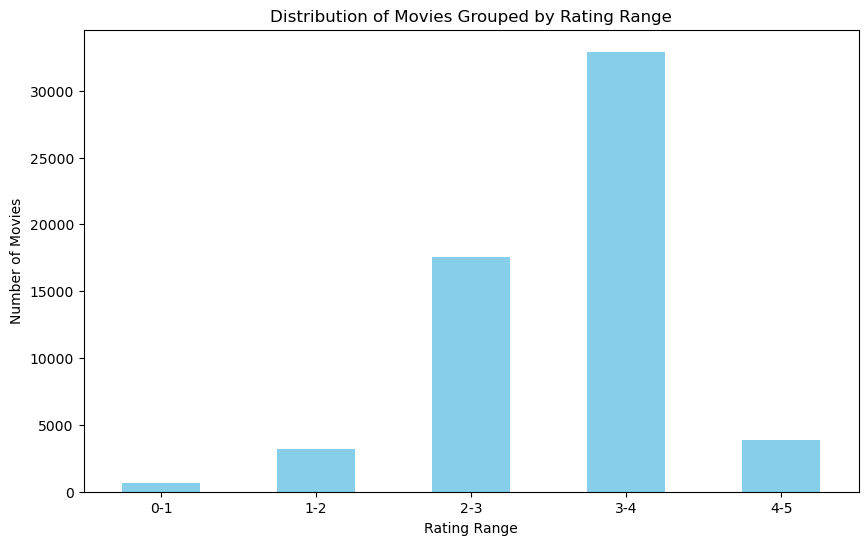

In [44]:

# Assuming df_ratings is already defined
# Group by ID and calculate the mean rating
mean_ratings = df_ratings.groupby('movieId')['rating'].mean().reset_index()

# Define bins for rating ranges
bins = [0, 1, 2, 3, 4, 5]  # Adjust bins as needed
labels = ['0-1', '1-2', '2-3', '3-4', '4-5']

# Add a new column to categorize mean ratings into bins
mean_ratings['rating_range'] = pd.cut(mean_ratings['rating'], bins=bins, labels=labels, right=False)

# Group by the rating range and count the number of movies in each range
rating_distribution = mean_ratings['rating_range'].value_counts().sort_index()

# Plot the distribution
plt.figure(figsize=(10, 6))
rating_distribution.plot(kind='bar', color='skyblue')
plt.title('Distribution of Movies Grouped by Rating Range')
plt.xlabel('Rating Range')
plt.ylabel('Number of Movies')
plt.xticks(rotation=0)
plt.show()

### Check the distribution per genre

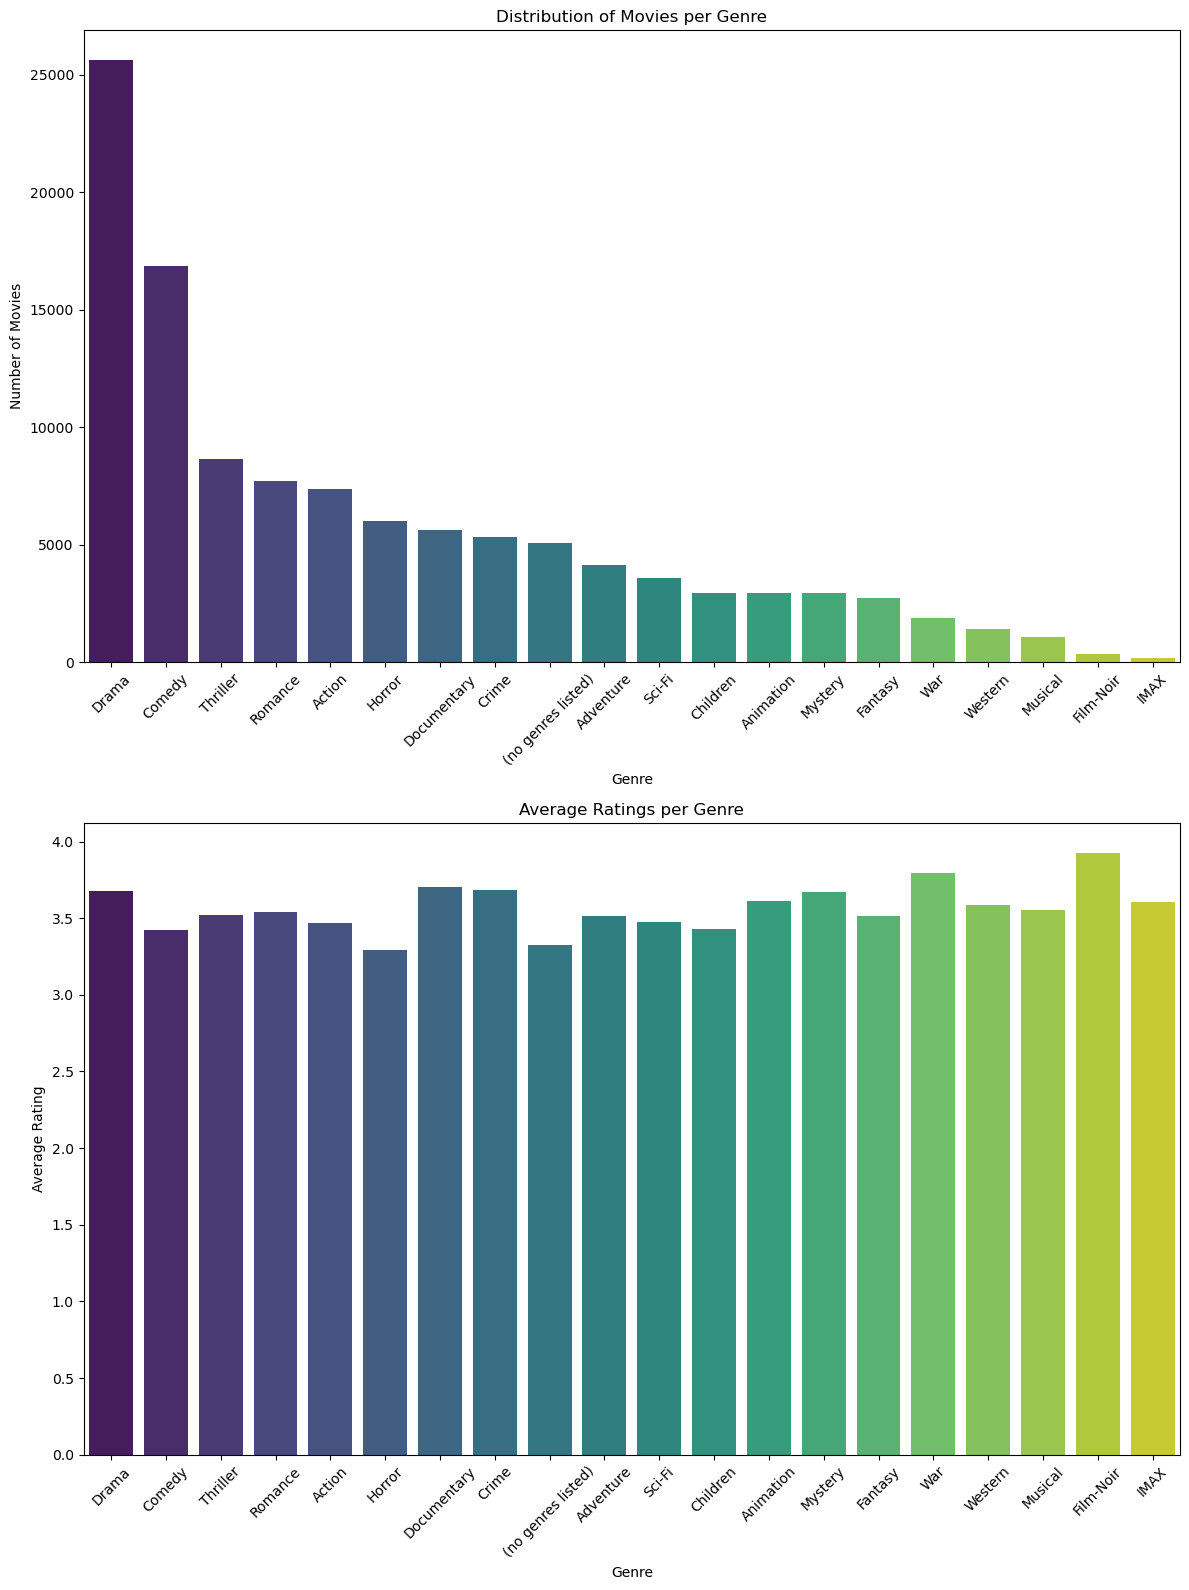

In [50]:
# Explode the genres column to have one genre per row
df_movies_exploded = df_movies.assign(genres=df_movies['genres'].str.split('|')).explode('genres')

# Count the number of movies per genre
genre_counts = df_movies_exploded['genres'].value_counts()

# Merge the movies and ratings dataframes
df_merged = pd.merge(df_movies_exploded, df_ratings, on='movieId')

# Calculate the average rating for each genre
average_ratings = df_merged.groupby('genres')['rating'].mean()

# Reorder the genres to have the same order in both plots
genres_order = genre_counts.index

# Plot both graphs in the same figure
fig, axes = plt.subplots(2, 1, figsize=(12, 16))

# Plot the distribution of movies per genre
sns.barplot(x=genres_order, y=genre_counts[genres_order], palette='viridis', ax=axes[0])
axes[0].set_title('Distribution of Movies per Genre')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Number of Movies')
axes[0].tick_params(axis='x', rotation=45)

# Plot the average ratings per genre
sns.barplot(x=genres_order, y=average_ratings[genres_order], palette='viridis', ax=axes[1])
axes[1].set_title('Average Ratings per Genre')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Average Rating')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


        userId  qtyRatings
72314    72315       32202
80973    80974        9178
137292  137293        8913
33843    33844        7919
20054    20055        7488
...        ...         ...
64554    64555          20
64416    64417          20
64425    64426          20
50          51          20
80284    80285          20

[162541 rows x 2 columns]


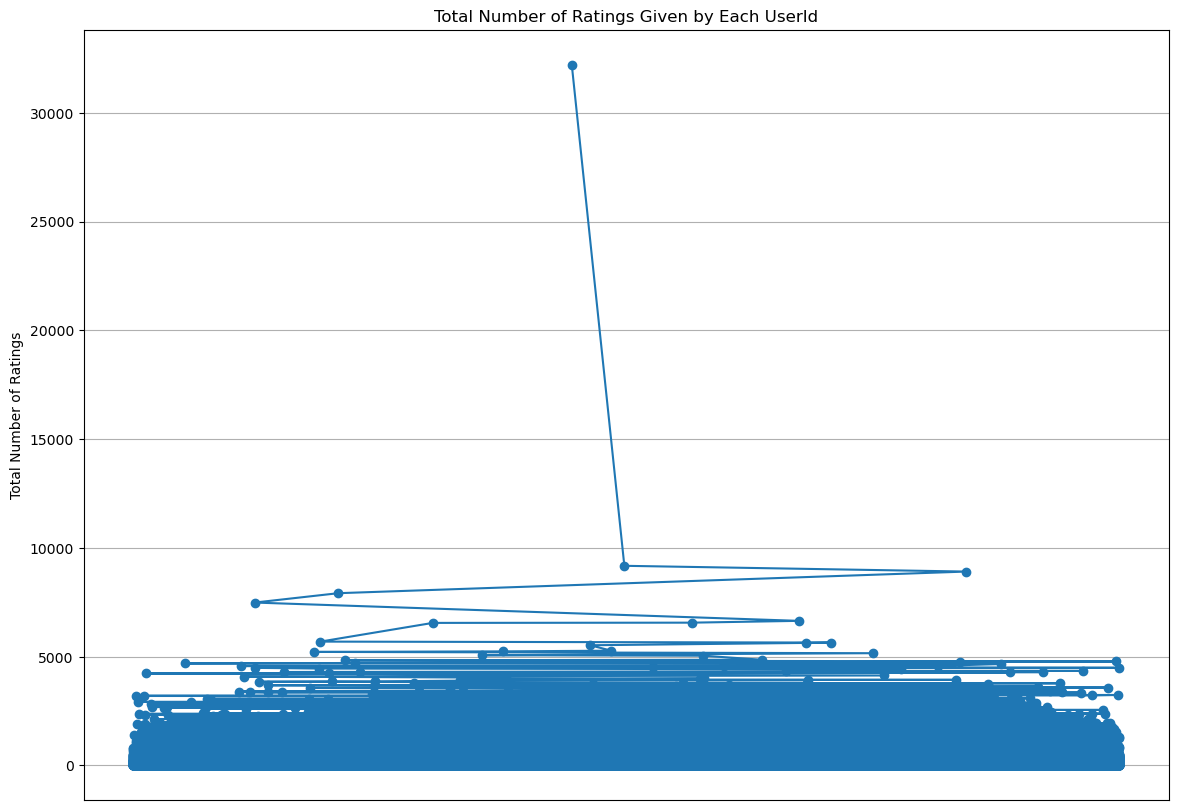

In [71]:
# Aggregate the total number of ratings per userId and rename the column to 'qtyRatings'
ratings_per_user = df_ratings.groupby('userId').size().reset_index(name='qtyRatings')

# Sort the userId in descending order based on the total number of ratings
ratings_per_user_sorted = ratings_per_user.sort_values(by='qtyRatings', ascending=False)
print(ratings_per_user_sorted)
# Create the line graph using matplotlib
plt.figure(figsize=(14, 10))
plt.plot(ratings_per_user_sorted['userId'], ratings_per_user_sorted['qtyRatings'], marker='o', linestyle='-')
plt.title('Total Number of Ratings Given by Each UserId')
plt.ylabel('Total Number of Ratings')
plt.xlabel('')
plt.xticks([])  # Omit the x-axis labels
plt.grid(True)
plt.show()